# CatBoost Regression Analysis

## Overview

This notebook implements a CatBoost regression model to predict used car prices. Unlike the RandomForest and MLP models which use one-hot encoded categorical features, CatBoost leverages its native categorical feature handling capabilities.

## Key Differences from RF/MLP Models

**Data Preprocessing:**
- **No one-hot encoding** of categorical features
- Categorical columns are kept in their raw string format
- Features are explicitly passed to CatBoost via the `cat_features` parameter

**Feature Count:**
- RF/MLP: 63 features (after one-hot encoding)
- CatBoost: ~10 features (6 categorical + 4 numeric)

**Advantages:**
- Better handling of high-cardinality features (e.g., 'brand' with 52 values)
- No information loss from one-hot encoding
- Automatic handling of missing values as a separate category
- Reduced dimensionality and faster training

## Train/Test Split

Uses the **exact same split** as RF/MLP models (`random_state=42`, 80/20 split) to ensure fair comparison.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from catboost import CatBoostRegressor

## 1. Data Loading and Preprocessing

Load the cleaned dataset and apply the same preprocessing as RF/MLP models, **except** one-hot encoding.

In [2]:
# Load data
filepath = "../Data/autos_random_50k_cleaned.csv"
autos = pd.read_csv(filepath, encoding="Latin-1")

# Initial preprocessing (same as RF/MLP)
autos = autos.drop(columns=["date_crawled", "Unnamed: 0", "last_seen", "car_name", "ad_created"])

# Convert transmission to boolean
autos['unrepaired_damage'] = autos['unrepaired_damage'].map({'nein': False, 'ja': True, 'Unknown': pd.NA})
autos['is_automatic'] = autos['transmission'].map({'manuell': False, 'automatik': True, 'Unknown': pd.NA})
autos.drop(columns=['transmission'], inplace=True)

# Convert ab_test to boolean
autos['is_test'] = autos['ab_test'].map({'control': False, 'test': True})
autos.drop(columns=['ab_test'], inplace=True)

# Extract region from postal code
autos['region'] = autos['postal_code'].apply(lambda x: str(x)[:1])
autos['zone'] = autos['postal_code'].apply(lambda x: str(x)[:2])
autos.drop(columns=['postal_code'], inplace=True)

# Clean up unknown values
autos['fuel_type'] = autos['fuel_type'].replace('Unknown', pd.NA)
autos['vehicle_type'] = autos['vehicle_type'].replace('Unknown', pd.NA)
autos['model'] = autos['model'].replace('Unknown', pd.NA)

print(f"Initial shape: {autos.shape}")
autos.head()

Initial shape: (37866, 14)


,price_EUR,vehicle_type,registration_year,power_ps,model,odometer_km,registration_month,fuel_type,brand,unrepaired_damage,is_automatic,is_test,region,zone
0,5200,cabrio,2002,235,astra,125000,5,<NA>,opel,False,False,True,4,47
1,3400,kleinwagen,2006,65,andere,125000,5,benzin,fiat,False,False,True,6,66
2,5200,suv,2009,220,xc_reihe,150000,3,diesel,volvo,True,True,True,7,72
3,750,kombi,2000,112,mondeo,150000,12,benzin,ford,<NA>,False,True,3,39
4,3522,limousine,2004,131,a4,150000,7,diesel,audi,False,False,True,5,51


In [3]:
# Additional preprocessing for CatBoost
autos_catboost = autos.drop(columns=['model', 'zone'])

# Clean fuel_type: keep only 'benzin', 'diesel', and Missing
autos_catboost['fuel_type'] = autos_catboost['fuel_type'].mask(
    autos_catboost['fuel_type'].notna() & ~autos_catboost['fuel_type'].isin(['benzin', 'diesel']),
    pd.NA
)

# Clean vehicle_type: replace 'andere' with Missing
autos_catboost['vehicle_type'] = autos_catboost['vehicle_type'].replace('andere', pd.NA)

# Create age variable
autos_catboost['age'] = 2016 - autos_catboost['registration_year']
autos_catboost.drop(columns=['registration_year'], inplace=True)
autos_catboost.drop(columns=['registration_month'], inplace=True)

# Convert missing values in categorical columns to string 'Missing'
# CatBoost handles these as a separate category
for col in ['is_automatic', 'unrepaired_damage', 'vehicle_type', 'fuel_type']:
    autos_catboost[col] = (
        autos_catboost[col]
        .astype(str)
        .replace('<NA>', 'Missing')
    )

print(f"\nAfter preprocessing shape: {autos_catboost.shape}")
print(f"\nColumn types:")
print(autos_catboost.dtypes)
autos_catboost.head()


After preprocessing shape: (37866, 11)

Column types:
price_EUR             int64
vehicle_type         object
power_ps              int64
odometer_km           int64
fuel_type            object
brand                object
unrepaired_damage    object
is_automatic         object
is_test                bool
region               object
age                   int64
dtype: object


,price_EUR,vehicle_type,power_ps,odometer_km,fuel_type,brand,unrepaired_damage,is_automatic,is_test,region,age
0,5200,cabrio,235,125000,Missing,opel,False,False,True,4,14
1,3400,kleinwagen,65,125000,benzin,fiat,False,False,True,6,10
2,5200,suv,220,150000,diesel,volvo,True,True,True,7,7
3,750,kombi,112,150000,benzin,ford,Missing,False,True,3,16
4,3522,limousine,131,150000,diesel,audi,False,False,True,5,12


In [4]:
# Display info about the dataset
autos_catboost.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37866 entries, 0 to 37865
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   price_EUR          37866 non-null  int64 
 1   vehicle_type       37866 non-null  object
 2   power_ps           37866 non-null  int64 
 3   odometer_km        37866 non-null  int64 
 4   fuel_type          37866 non-null  object
 5   brand              37866 non-null  object
 6   unrepaired_damage  37866 non-null  object
 7   is_automatic       37866 non-null  object
 8   is_test            37866 non-null  bool  
 9   region             37866 non-null  object
 10  age                37866 non-null  int64 
dtypes: bool(1), int64(4), object(6)
memory usage: 2.9+ MB


## 2. Feature Documentation

### Categorical Features (6 features)
These features will be passed to CatBoost's `cat_features` parameter:
1. **vehicle_type** - Type of vehicle (cabrio, kleinwagen, suv, kombi, limousine, bus, coupe, Missing)
2. **fuel_type** - Fuel type (benzin, diesel, Missing)
3. **brand** - Car manufacturer (52 unique brands)
4. **unrepaired_damage** - Whether car has unrepaired damage (True, False, Missing)
5. **is_automatic** - Whether transmission is automatic (True, False, Missing)
6. **region** - First digit of postal code (regions 1-9)

### Numeric Features (4 features)
1. **power_ps** - Engine power in PS
2. **odometer_km** - Mileage in kilometers
3. **age** - Age of vehicle (2016 - registration_year)
4. **is_test** - A/B test group (boolean)

### Target Variable
- **price_EUR** - Car price in Euros

In [5]:
# Display unique values for categorical features
categorical_features = ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']

print("Unique values per categorical feature:\n")
for col in categorical_features:
    n_unique = autos_catboost[col].nunique()
    print(f"{col}: {n_unique} unique values")
    if n_unique <= 10:
        print(f"  Values: {sorted(autos_catboost[col].unique())}")
    print()

Unique values per categorical feature:

vehicle_type: 8 unique values
  Values: ['Missing', 'bus', 'cabrio', 'coupe', 'kleinwagen', 'kombi', 'limousine', 'suv']

fuel_type: 3 unique values
  Values: ['Missing', 'benzin', 'diesel']

brand: 40 unique values

unrepaired_damage: 3 unique values
  Values: ['False', 'Missing', 'True']

is_automatic: 3 unique values
  Values: ['False', 'Missing', 'True']

region: 9 unique values
  Values: ['1', '2', '3', '4', '5', '6', '7', '8', '9']



## 3. Train/Test Split

Using the **exact same split** as RF/MLP models: `random_state=42`, 80% train, 20% test.

In [6]:
# Prepare features and target
X = autos_catboost.drop(columns=['price_EUR'])
y = autos_catboost['price_EUR']

# Train/test split with same random_state as RF/MLP
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"\nFeatures: {list(X.columns)}")

Training set: (30292, 10)
Test set: (7574, 10)

Features: ['vehicle_type', 'power_ps', 'odometer_km', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'is_test', 'region', 'age']


## 4. CatBoost Model Training

### Model Configuration
- **iterations**: 2000 (with early stopping)
- **learning_rate**: 0.05
- **depth**: 8
- **loss_function**: RMSE
- **random_seed**: 42 (for reproducibility)
- **early_stopping_rounds**: 50
- **eval_set**: Test set (no additional validation split)
- **cat_features**: Explicitly defined categorical features

In [7]:
# Define categorical features for CatBoost
cat_features = ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']

print(f"Categorical features passed to CatBoost: {cat_features}")
print(f"Number of categorical features: {len(cat_features)}")
print(f"Number of numeric features: {X_train.shape[1] - len(cat_features)}")

Categorical features passed to CatBoost: ['vehicle_type', 'fuel_type', 'brand', 'unrepaired_damage', 'is_automatic', 'region']
Number of categorical features: 6
Number of numeric features: 4


In [8]:
# Initialize CatBoost model
model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=8,
    loss_function='RMSE',
    random_seed=42,
    early_stopping_rounds=50,
    verbose=100,
    cat_features=cat_features
)

print("CatBoost model initialized with baseline configuration.")
print("\nTraining started...\n")

CatBoost model initialized with baseline configuration.

Training started...



In [9]:
# Train the model
model.fit(
    X_train, y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

print("\nTraining completed!")
print(f"Best iteration: {model.get_best_iteration()}")

0:	learn: 11539.8323246	test: 10366.1026460	best: 10366.1026460 (0)	total: 311ms	remaining: 10m 21s
100:	learn: 4232.3711231	test: 4151.1820431	best: 4150.4742616 (99)	total: 14.1s	remaining: 4m 25s
200:	learn: 3596.6771197	test: 3991.1825683	best: 3991.1825683 (200)	total: 27s	remaining: 4m 1s
300:	learn: 3217.8973210	test: 3945.3553477	best: 3944.3242899 (292)	total: 40.1s	remaining: 3m 46s
400:	learn: 2968.7198239	test: 3915.0608577	best: 3914.3942790 (396)	total: 1m 2s	remaining: 4m 7s
500:	learn: 2768.7003218	test: 3897.0809812	best: 3895.9264654 (461)	total: 1m 18s	remaining: 3m 54s
600:	learn: 2640.0686087	test: 3885.8130358	best: 3885.8130358 (600)	total: 1m 34s	remaining: 3m 40s
700:	learn: 2529.9498864	test: 3886.7443303	best: 3882.0958206 (655)	total: 1m 50s	remaining: 3m 24s
Stopped by overfitting detector  (50 iterations wait)

bestTest = 3882.095821
bestIteration = 655

Shrink model to first 656 iterations.

Training completed!
Best iteration: 655


## 5. Model Evaluation

Using the same evaluation metrics as RF/MLP: MAE and R².

In [10]:
# Make predictions on test set
y_pred = model.predict(X_test)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\n--- Evaluation on Test Set ---")
print(f"Mean Absolute Error (MAE): {mae:.2f} EUR")
print(f"R-squared (R²): {r2:.4f}")


--- Evaluation on Test Set ---
Mean Absolute Error (MAE): 1569.17 EUR
R-squared (R²): 0.8677


## 6. Visualization: Actual vs Predicted Prices

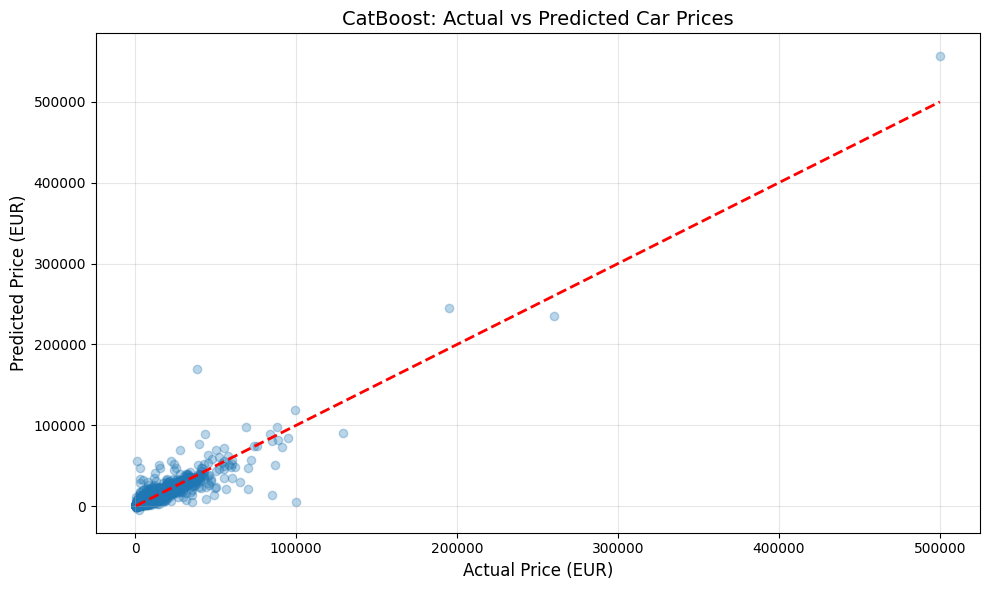

In [11]:
# Plot actual vs predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price (EUR)', fontsize=12)
plt.ylabel('Predicted Price (EUR)', fontsize=12)
plt.title('CatBoost: Actual vs Predicted Car Prices', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

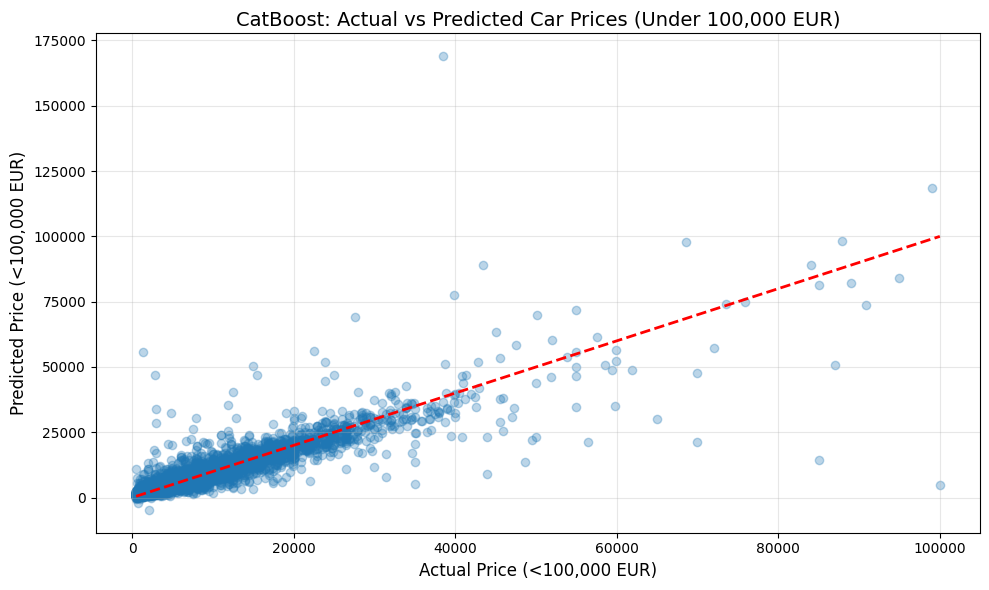

In [12]:
# Plot for prices under 100,000 EUR (for better visualization)
mask = y_test < 100000
plt.figure(figsize=(10, 6))
plt.scatter(y_test[mask], y_pred[mask], alpha=0.3)
plt.plot([y_test[mask].min(), y_test[mask].max()], 
         [y_test[mask].min(), y_test[mask].max()], 'r--', lw=2)
plt.xlabel('Actual Price (<100,000 EUR)', fontsize=12)
plt.ylabel('Predicted Price (<100,000 EUR)', fontsize=12)
plt.title('CatBoost: Actual vs Predicted Car Prices (Under 100,000 EUR)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Feature Importance Analysis

CatBoost provides built-in feature importance scores that account for both categorical and numeric features.

In [13]:
# Get feature importances
feature_importance = model.get_feature_importance()
feature_names = X_train.columns

# Create DataFrame for better visualization
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("Feature Importances (sorted):")
print(importance_df.to_string(index=False))

Feature Importances (sorted):
          feature  importance
         power_ps   34.355790
      odometer_km   20.582888
              age   17.636247
     is_automatic    9.072598
            brand    6.180991
     vehicle_type    6.106287
        fuel_type    3.737527
unrepaired_damage    1.106884
           region    0.975219
          is_test    0.245569


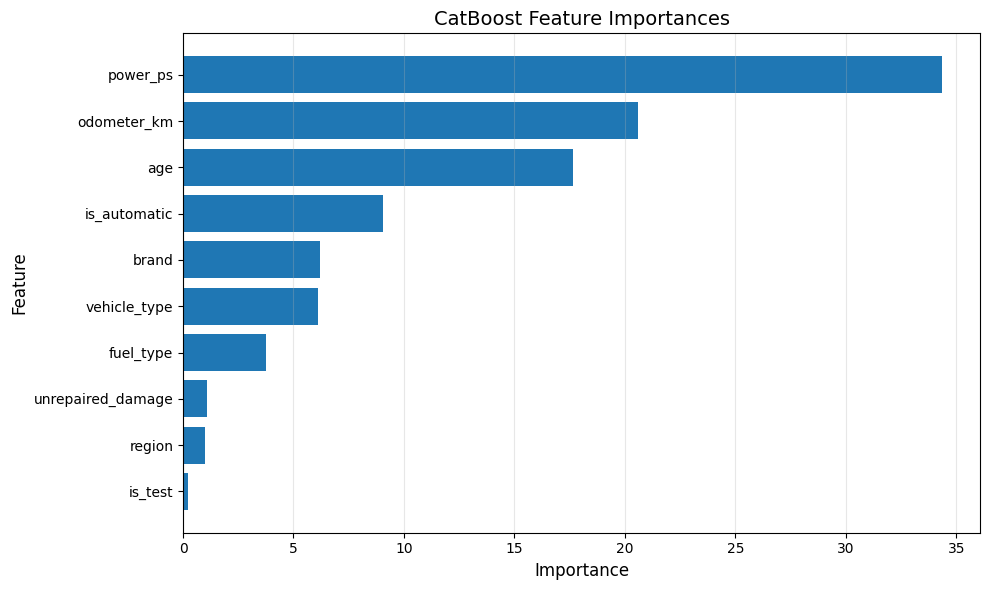

In [14]:
# Visualize feature importances
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('CatBoost Feature Importances', fontsize=14)
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

## 8. Residual Analysis

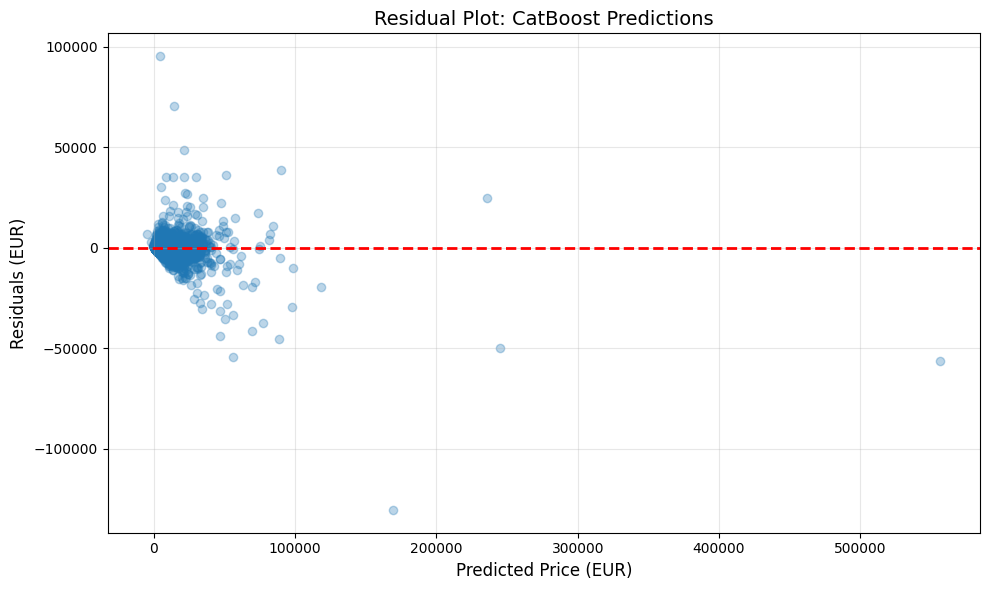

In [15]:
# Calculate residuals
residuals = y_test - y_pred

# Plot residuals
plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.3)
plt.axhline(y=0, color='r', linestyle='--', lw=2)
plt.xlabel('Predicted Price (EUR)', fontsize=12)
plt.ylabel('Residuals (EUR)', fontsize=12)
plt.title('Residual Plot: CatBoost Predictions', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

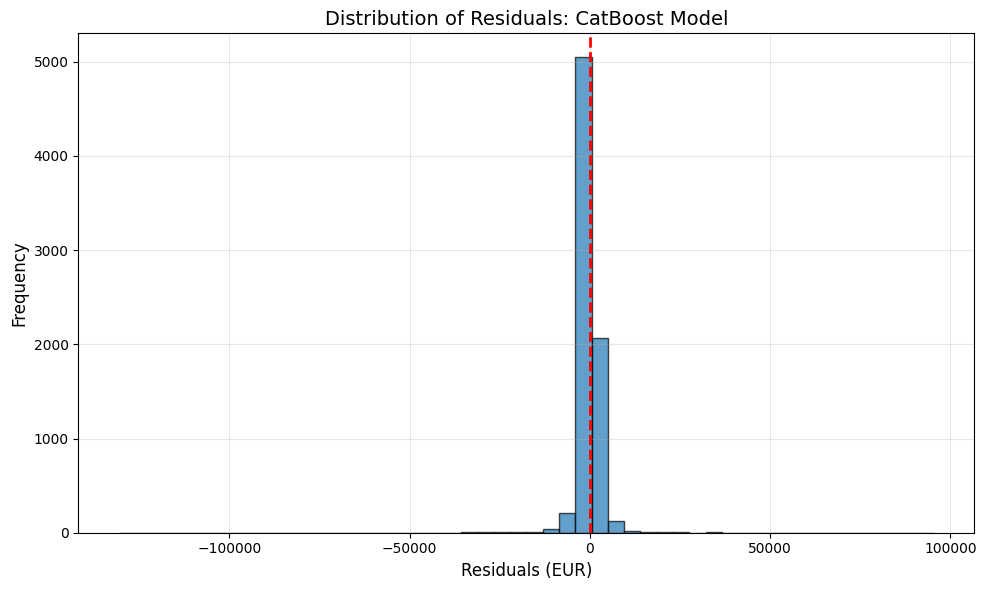

Mean Residual: -121.85 EUR
Std Residual: 3880.44 EUR


In [16]:
# Distribution of residuals
plt.figure(figsize=(10, 6))
plt.hist(residuals, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals (EUR)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals: CatBoost Model', fontsize=14)
plt.axvline(x=0, color='r', linestyle='--', lw=2)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Mean Residual: {residuals.mean():.2f} EUR")
print(f"Std Residual: {residuals.std():.2f} EUR")

## 9. Summary and Comparison

### CatBoost Implementation Summary

**Data Characteristics:**
- Total features: 10 (6 categorical + 4 numeric)
- No one-hot encoding applied
- Missing values treated as separate category

**Model Configuration:**
- Algorithm: CatBoost (gradient boosting)
- Categorical handling: Native support via `cat_features`
- Early stopping: Yes (50 rounds on test set)
- Random seed: 42 (same as RF/MLP)

**Key Advantages:**
1. **Reduced dimensionality**: 10 features vs 63 one-hot encoded features
2. **Better categorical handling**: No information loss from encoding
3. **Automatic missing value handling**: Treats as separate category
4. **Efficient with high-cardinality features**: Brand has 52 unique values

**Comparison with RF/MLP:**
- Same train/test split (random_state=42, 80/20)
- Same evaluation metrics (MAE, R²)
- Same target variable (price_EUR)
- Different feature representation (raw vs one-hot encoded)

In [17]:
# Final summary statistics
print("="*60)
print("CATBOOST MODEL SUMMARY")
print("="*60)
print(f"\nModel Configuration:")
print(f"  - Iterations: {model.get_param('iterations')}")
print(f"  - Learning Rate: {model.get_param('learning_rate')}")
print(f"  - Depth: {model.get_param('depth')}")
print(f"  - Best Iteration: {model.get_best_iteration()}")
print(f"\nData:")
print(f"  - Training samples: {len(X_train)}")
print(f"  - Test samples: {len(X_test)}")
print(f"  - Total features: {X_train.shape[1]}")
print(f"  - Categorical features: {len(cat_features)}")
print(f"  - Numeric features: {X_train.shape[1] - len(cat_features)}")
print(f"\nPerformance:")
print(f"  - MAE: {mae:.2f} EUR")
print(f"  - R²: {r2:.4f}")
print(f"  - Mean Residual: {residuals.mean():.2f} EUR")
print(f"  - Std Residual: {residuals.std():.2f} EUR")
print(f"\nTop 3 Most Important Features:")
for i, row in importance_df.head(3).iterrows():
    is_cat = row['feature'] in cat_features
    feat_type = 'categorical' if is_cat else 'numeric'
    print(f"  {row['feature']:20s} ({feat_type}): {row['importance']:.2f}")
print("="*60)

CATBOOST MODEL SUMMARY

Model Configuration:
  - Iterations: 2000
  - Learning Rate: 0.05
  - Depth: 8
  - Best Iteration: 655

Data:
  - Training samples: 30292
  - Test samples: 7574
  - Total features: 10
  - Categorical features: 6
  - Numeric features: 4

Performance:
  - MAE: 1569.17 EUR
  - R²: 0.8677
  - Mean Residual: -121.85 EUR
  - Std Residual: 3880.44 EUR

Top 3 Most Important Features:
  power_ps             (numeric): 34.36
  odometer_km          (numeric): 20.58
  age                  (numeric): 17.64
